In [47]:
import numpy as np
import matplotlib.pyplot as plt

In [48]:
# Load data from ideal simulation
data = np.load('pp_tb_th_boot_ota_ideal.npz')

# List all array names in the file
print(data.files)  # Output: ['array1', 'array2']

# Access a specific array
hd3_ideal = data['hd3']
bins = data['bins']
data.close()

['sfdr', 'hd3', 'bins']


In [49]:
# Load data from simulation with bottom plate
data = np.load('pp_tb_th_boot_ota.npz')

# List all array names in the file
print(data.files)  # Output: ['array1', 'array2']

# Access a specific array
hd3 = data['hd3']
data.close()

['sfdr', 'hd3', 'bins']


In [50]:
# Load data from simulation with top plate
data = np.load('pp_tb_th_boot.npz')

# List all array names in the file
print(data.files)  # Output: ['array1', 'array2']

# Access a specific array
hd3_top = data['hd3']
data.close()

['sfdr', 'hd3', 'bins']


In [51]:
# Analytical data
vov = 0.73
vm = 0.20
fs = 500e6
nfft = 32
fin = bins*fs/nfft
c = 5e-12
cb = 5e-12
cp = 0.1e-12
gds = 75e-3
fbw=1/(2*np.pi*c/gds)
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb)**2)
print(fbw/1e6)

2387.3241463784298


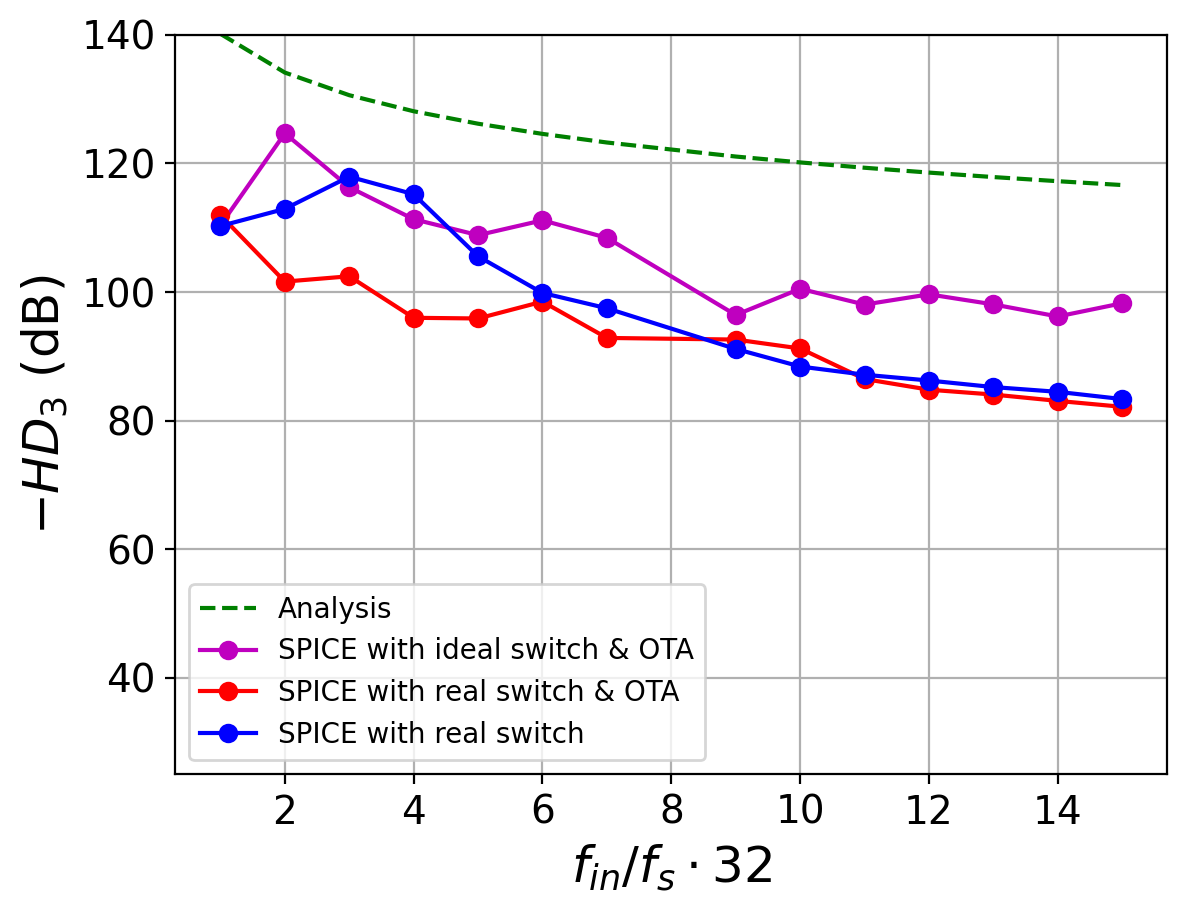

In [52]:
plt.rcParams['figure.dpi'] = 200
plt.plot(bins, hd3_calc, "g--", label='Analysis')
plt.plot(bins, hd3_ideal, "m-o", label='SPICE with ideal switch & OTA')
plt.plot(bins, hd3, "r-o", label='SPICE with real switch & OTA')
plt.plot(bins, hd3_top, "b-o", label='SPICE with real switch')
plt.grid()
plt.xlabel("$f_{in}/f_s \\cdot 32$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(25, 140)
plt.grid(True)
plt.legend()
plt.show()